# Sample trajectories: noise-induced sustained oscillations

Builds `figures/sample_trajectories_expou.pdf` (Fig. `fig:sample_traj`).

Model: the role-reversal system driven by an **exponential Ornstein–Uhlenbeck** attack rate

$$G(U) = g_{\min} + \Delta\,e^{U},\qquad \Delta=\bar g-g_{\min},\qquad
dU = -\alpha U\,dt + \sigma_U\,dB,\qquad g_{\min}=\tfrac{sk}{b}.$$

The driver is specified by $\alpha$ and the stationary variance $v=\sigma_U^2/(2\alpha)$ of the
*latent* process $U$, so that the amplitude $\mathrm{std}(U)=\sqrt v$ is held fixed while $\alpha$
alone sets the correlation time $1/\alpha$.

Here $\alpha = 0.133$ sits near the resonance value, matching the natural frequency
$\omega_0\approx0.128$ of the linearization at $E^*(\bar g = 0.45)$.

Requires `sde.py` and `mean_shift_expou.py` on the path.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sde import Params, E_star, jacobian, g_hopf, g_min_default, OUNoise
from mean_shift_expou import mean_shifts, second_moments

import sample_trajectories_expou as st

p, alpha, sigma = st.P, st.ALPHA, st.SIGMA
g_min, g1 = g_min_default(p), g_hopf(p)

print(f"g_min = sk/b        = {g_min:.4f}")
print(f"deterministic Hopf  g_1 = {g1:.6f}")
print(f"alpha = {alpha}   (correlation time 1/alpha = {1/alpha:.2f})")
print(f"v = sigma_U^2/(2 alpha) = {sigma**2/(2*alpha):.6f}   "
      f"sigma_U = {sigma:.6f}   std(U) = {np.sqrt(sigma**2/(2*alpha)):.4f}")

g_min = sk/b        = 0.1500
deterministic Hopf  g_1 = 0.438483
alpha = 0.133   (correlation time 1/alpha = 7.52)
v = sigma_U^2/(2 alpha) = 0.001250   sigma_U = 0.018235   std(U) = 0.0354


## Driver and equilibrium diagnostics

Note that $\bar g$ is the **median** of the stationary law of $G$, not its mean: the convexity of
$e^{U}$ pushes $\mathbb{E}[G]=g_{\min}+\Delta e^{v/2}$ above $\bar g$ by $O(v)$. The amplitude
$\sqrt v$ is the standard deviation of the *log*-driver; the standard deviation of $G$ itself is
$\Delta\sqrt{e^{v}(e^{v}-1)}\approx\Delta\sqrt v$, which is what should be compared to $\bar g$.

In [2]:
rows = []
for g_bar, label in st.CASES:
    pg = p.with_(g=g_bar)
    eq = E_star(pg)
    ev = np.linalg.eigvals(jacobian(eq, pg))
    w0 = np.max(np.abs(ev.imag))
    ou = OUNoise(g_bar=g_bar, sigma=sigma, alpha=alpha, g_min=g_min)
    ms = mean_shifts(p, g_bar, sigma, alpha)
    rows.append((g_bar, eq, ev.real.max(), w0, ou, ms))

    print(f"g_bar = {g_bar}   ({label})")
    print(f"    E*            = ({eq[0]:.4f}, {eq[1]:.4f}, {eq[2]:.4f})")
    print(f"    max Re(lambda) = {ev.real.max():+.5f}   omega_0 = {w0:.4f}"
          f"   (period {2*np.pi/w0:.1f},  1/omega_0 = {1/w0:.2f})")
    print(f"    Delta          = {ou.delta(p):.4f}")
    print(f"    std(G)         = {ou.stationary_std_G(p):.5f}"
          f"   ({100*ou.stationary_std_G(p)/g_bar:.2f}% of g_bar)")
    print(f"    E[G] - g_bar   = {ou.stationary_mean_G(p) - g_bar:+.6f}")
    if ms is None:
        print("    mean shift     : E* unstable -- small-noise expansion does not apply")
    else:
        d = ms[0]
        print(f"    mean shift     = ({d[0]:+.5f}, {d[1]:+.5f}, {d[2]:+.5f})"
              f"   [{100*d[0]/eq[0]:+.2f}% in x]")
    print()

g_bar = 0.42   (below $g_1$)
    E*            = (3.3333, 0.6111, 1.2222)
    max Re(lambda) = +0.00438   omega_0 = 0.1400   (period 44.9,  1/omega_0 = 7.14)
    Delta          = 0.2700
    std(G)         = 0.00955   (2.27% of g_bar)
    E[G] - g_bar   = +0.000169
    mean shift     : E* unstable -- small-noise expansion does not apply

g_bar = 0.45   (just above $g_1$)
    E*            = (4.0000, 0.6000, 1.2000)
    max Re(lambda) = -0.00296   omega_0 = 0.1280   (period 49.1,  1/omega_0 = 7.81)
    Delta          = 0.3000
    std(G)         = 0.01062   (2.36% of g_bar)
    E[G] - g_bar   = +0.000188
    mean shift     = (+0.16684, -0.00278, -0.00556)   [+4.17% in x]

g_bar = 0.5   (deterministically stable)
    E*            = (6.0000, 0.5667, 1.1333)
    max Re(lambda) = -0.01954   omega_0 = 0.1015   (period 61.9,  1/omega_0 = 9.86)
    Delta          = 0.3500
    std(G)         = 0.01239   (2.48% of g_bar)
    E[G] - g_bar   = +0.000219
    mean shift     = (+0.11173, -0.00186, -0.

## Simulate

Euler–Maruyama on the latent driver $U$, classical RK4 on the populations in log-coordinates
(so positivity is exact), $dt = 0.01$, $t_{\mathrm{end}} = 1500$, seed 1 shared by the
deterministic and stochastic runs of each row.

In [3]:
runs = st.run_cases()
print(f"t_end = {st.T_END},  dt = {st.DT},  store_every = {st.STORE_EVERY},  seed = {st.SEED}")
print(f"phase-plane burn-in: t > {st.T_BURN_PHASE}")

t_end = 1500.0,  dt = 0.01,  store_every = 5,  seed = 1
phase-plane burn-in: t > 500.0


## Figure

saved: ./sample_trajectories_expou.png figures/sample_trajectories_expou.pdf


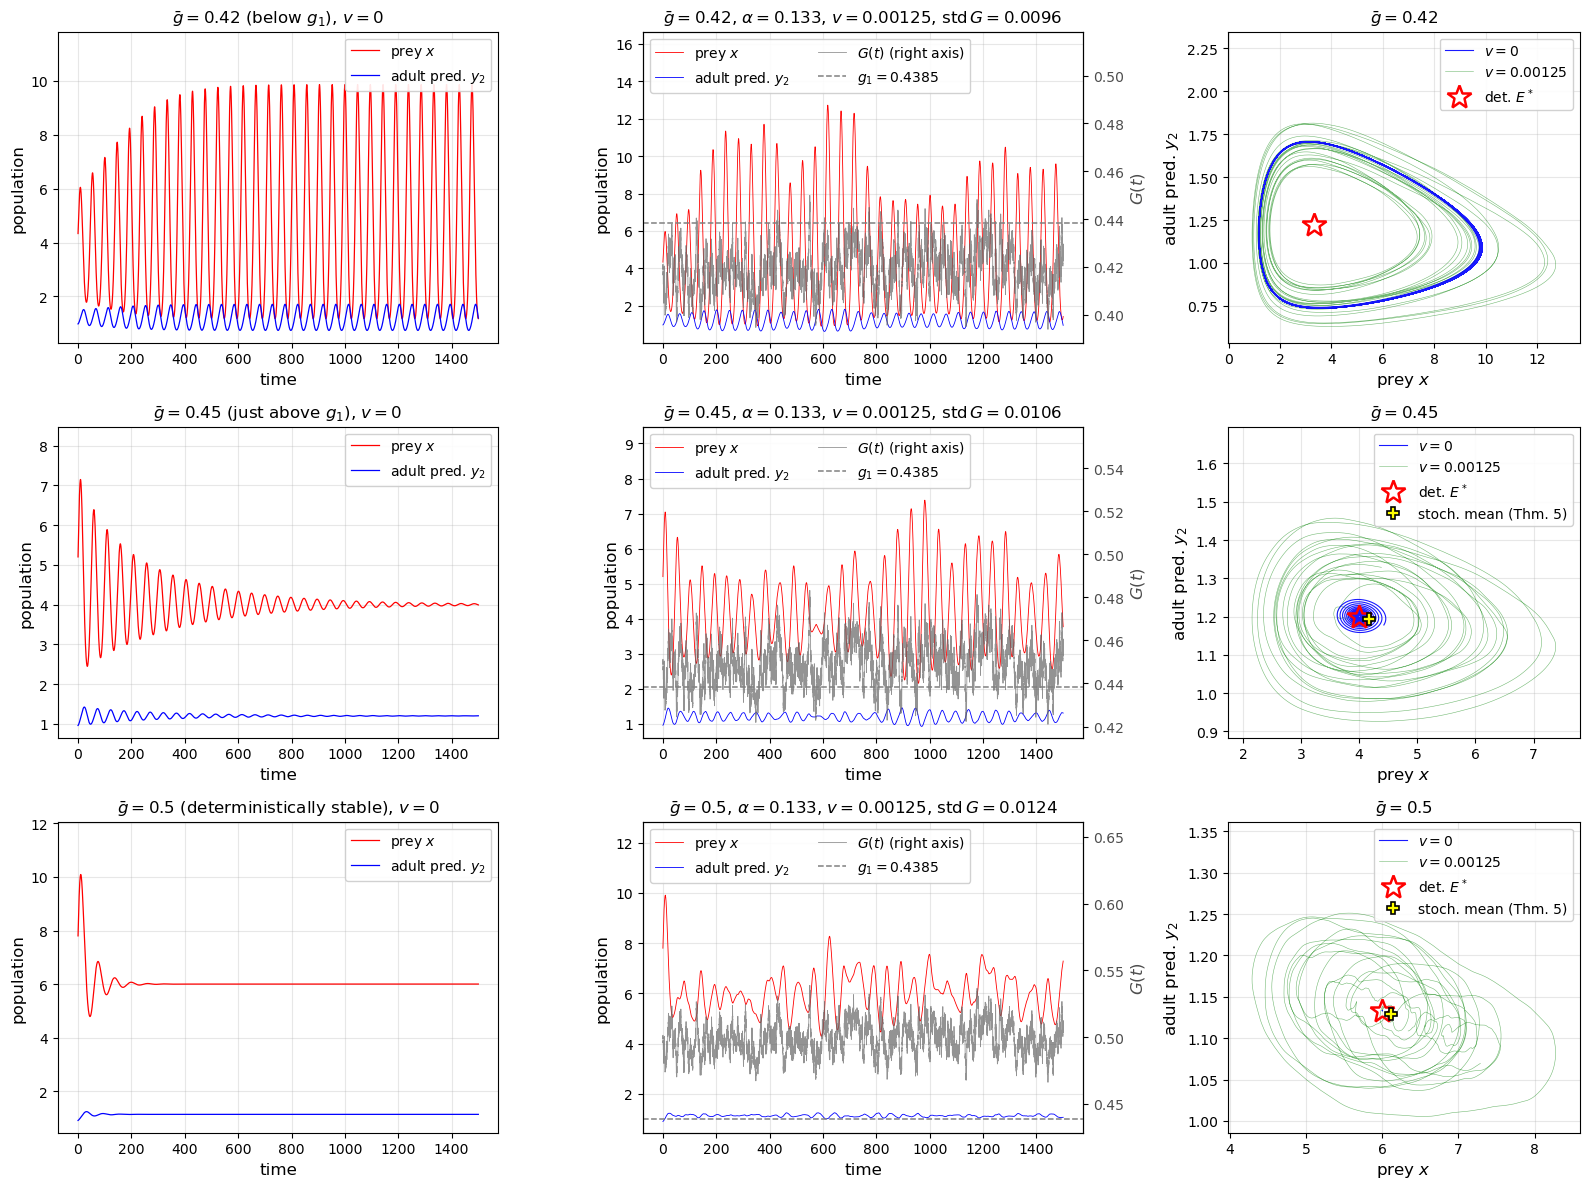

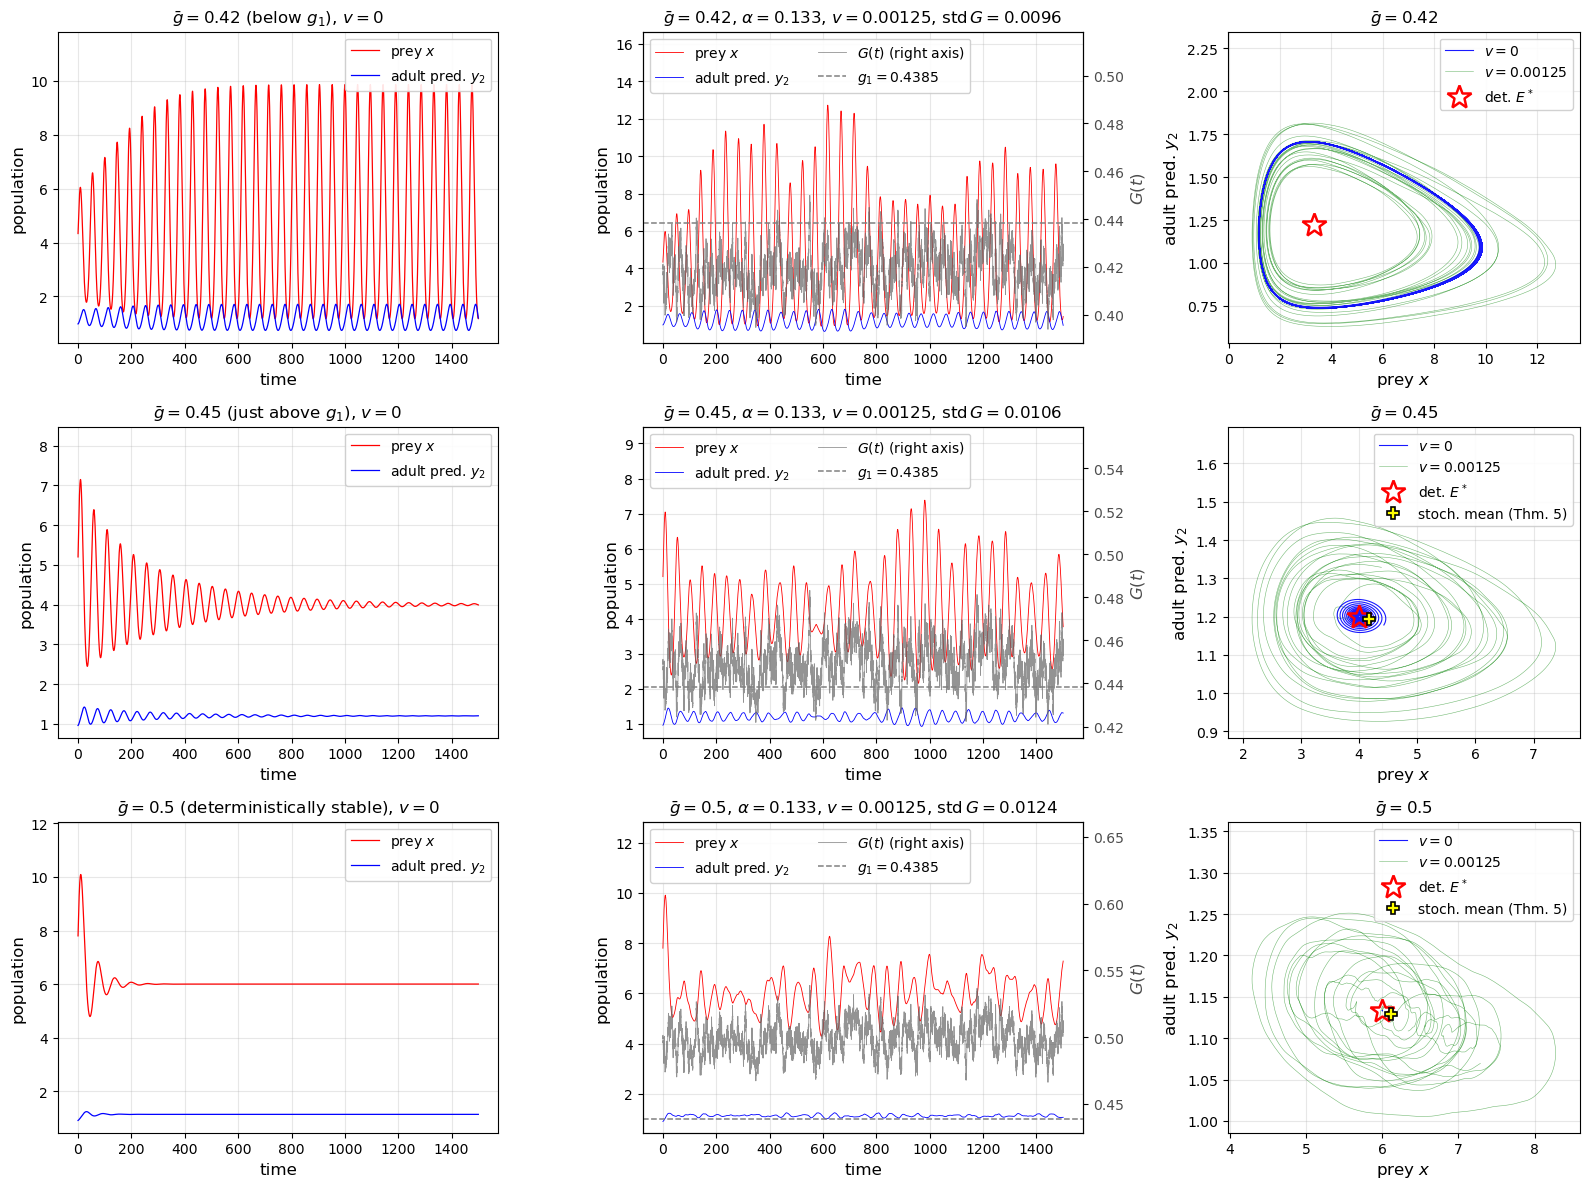

In [4]:
fig, runs = st.make_figure(runs=runs, g1=g1)

# Adjust if the notebook is not run from the directory holding the paper tree.
st.OUTDIR_PNG = "."
st.OUTDIR_PDF = "figures"
print("saved:", *st.save(fig))

fig

## Numbers quoted in the text

Ranges over the plotted window (after the phase-plane burn-in), for checking the sentences in
Section `sec:sample-traj` against what the figure actually shows.

In [5]:
tb = st.T_BURN_PHASE
for run in runs:
    print(f"g_bar = {run['g_bar']}   (E* x = {run['eq'][0]:.3f})")
    for key, name in (("det", "sigma = 0     "), ("noi", f"sigma = {sigma:.4f}")):
        t, X = run[key]
        m = t > tb
        print(f"    {name}:  x in [{X[m,0].min():6.3f}, {X[m,0].max():6.3f}]"
              f"   mean {X[m,0].mean():6.3f}"
              f"   |  y2 in [{X[m,2].min():.3f}, {X[m,2].max():.3f}]"
              f"   mean {X[m,2].mean():.4f}")
    t, X = run["noi"]
    m = t > tb
    print(f"    driver        :  G in [{X[m,3].min():.4f}, {X[m,3].max():.4f}]"
          f"   mean {X[m,3].mean():.4f}   std {X[m,3].std():.4f}")
    ms = mean_shifts(p, run["g_bar"], sigma, alpha)
    if ms is not None:
        d, eqt = ms
        print(f"    theory        :  E[x] = {eqt[0] + d[0]:.4f}   (empirical {X[m,0].mean():.4f})"
              f"   |  E[y2] = {eqt[2] + d[2]:.4f}   (empirical {X[m,2].mean():.4f})")
    print()

g_bar = 0.42   (E* x = 3.333)
    sigma = 0     :  x in [ 1.174,  9.865]   mean  4.705   |  y2 in [0.736, 1.707]   mean 1.1765
    sigma = 0.0182:  x in [ 0.909, 12.729]   mean  4.580   |  y2 in [0.630, 1.814]   mean 1.1796
    driver        :  G in [0.3939, 0.4499]   mean 0.4202   std 0.0092

g_bar = 0.45   (E* x = 4.000)
    sigma = 0     :  x in [ 3.621,  4.458]   mean  4.004   |  y2 in [1.158, 1.245]   mean 1.2002
    sigma = 0.0182:  x in [ 2.156,  7.382]   mean  4.224   |  y2 in [0.926, 1.457]   mean 1.1930
    driver        :  G in [0.4210, 0.4832]   mean 0.4502   std 0.0102
    theory        :  E[x] = 4.1668   (empirical 4.2237)   |  E[y2] = 1.1944   (empirical 1.1930)

g_bar = 0.5   (E* x = 6.000)
    sigma = 0     :  x in [ 6.000,  6.000]   mean  6.000   |  y2 in [1.133, 1.133]   mean 1.1333
    sigma = 0.0182:  x in [ 4.294,  8.274]   mean  6.078   |  y2 in [1.005, 1.251]   mean 1.1302
    driver        :  G in [0.4662, 0.5388]   mean 0.5003   std 0.0119
    theory        : 